In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm import trange
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

from analysis.utils import extract_variables

In [3]:
data = load_run_data(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions')

Found 9 episode directories in /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


In [4]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [5]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


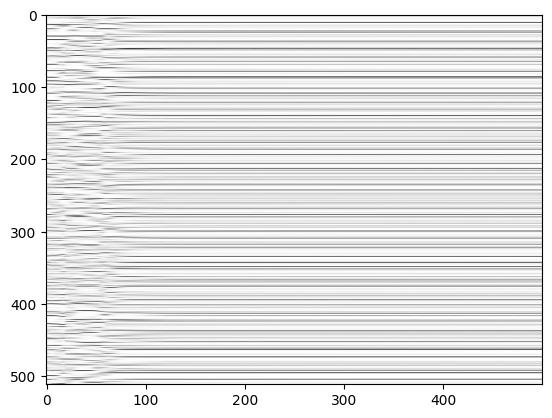

In [6]:
plt.imshow(exp_vars['latent_states'][8].T[:, :500],
           aspect='auto',
           cmap='gray_r')

## Linear decoding


In [7]:
def make_lagged_pairs_for_episode(x_ep, y_ep, lag):
    """Build (X, Y) pairs within one episode for given lag."""
    T = len(x_ep)
    if lag >= 0:
        t_src = np.arange(0, T - lag)
        t_tgt = t_src + lag

    elif lag < 0:
        # Predict the past: (z_t, y_{t+lag}) = (z_t, y_{t-|lag|})
        shift = abs(lag)
        t_src = np.arange(shift, T)
        t_tgt = np.arange(0, T - shift)

    return x_ep[t_src], y_ep[t_tgt]


def bootstrap_ci(vals, alpha=0.05, n_boot=1000):
    rng = np.random.RandomState(0)
    boot_means = np.zeros(n_boot)
    for b in range(n_boot):
        resampled = rng.choice(vals, size=len(vals), replace=True)
        boot_means[b] = np.mean(resampled)

    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return (lower, upper)

In [8]:
def evaluate_lags_leave_k_out(x_eps,
                              y_eps,
                              lags,
                              k_holdout=1,
                              model='linear_regression',
                              max_combinations=None,
                              add_bootstrap_ci=False,
                              alpha=0.05,
                              n_bootstrap=1000,
                              shuffle_X=False,
                              shuffle_y=False):
    """
    Args:
        x_eps: list of [N_eps_i, L] arrays
        y_eps: list of [N_eps_i, D] arrays   
    """
    n_eps = len(x_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    # Enumerate folds (all combinations or sampled subset)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        np.random.seed(0)
        all_combos = list(
            np.random.choice(len(all_combos), max_combinations, replace=False))

    if shuffle_X:
        x_eps = [np.random.permutation(x_ep) for x_ep in x_eps]
    if shuffle_y:
        y_eps = [np.random.permutation(y_ep) for y_ep in y_eps]

    r2_by_lag = {lag: [] for lag in lags}
    model_by_lag = {lag: [] for lag in lags}

    for test_idxs in tqdm(all_combos):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        for lag in lags:
            # Collect training pairs
            X_train_list, Y_train_list = [], []
            for i in train_idxs:
                X_i, Y_i = make_lagged_pairs_for_episode(
                    x_eps[i], y_eps[i], lag)
                X_train_list.append(X_i)
                Y_train_list.append(Y_i)

            X_train = np.concatenate(X_train_list, axis=0)
            Y_train = np.concatenate(Y_train_list, axis=0)

            if model == 'linear_regression':
                model_to_fit = LinearRegression()
            elif model == 'lasso':
                model_to_fit = Lasso(alpha=0.001)
            else:
                raise ValueError(f"Model {model} not supported")

            # Fit model on training set
            model_to_fit = model_to_fit.fit(X_train, Y_train)

            # Evaluate on each held-out episode
            fold_r2s = []
            for j in test_idxs:
                X_te, Y_te = make_lagged_pairs_for_episode(
                    x_eps[j], y_eps[j], lag)
                Y_pred = model_to_fit.predict(X_te)
                r2 = r2_score(Y_te, Y_pred, multioutput='variance_weighted')
                fold_r2s.append(r2)

            r2_by_lag[lag].append(
                np.mean(fold_r2s))  # mean R² over held-out eps in this fold

            model_by_lag[lag] = model_to_fit

    # Aggregate mean and std over folds
    r2_mean = {lag: np.mean(vals) for lag, vals in r2_by_lag.items()}
    r2_std = {lag: np.std(vals, ddof=1) for lag, vals in r2_by_lag.items()}

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_lag': r2_by_lag,
        'model_by_lag': model_by_lag,
    }

    if add_bootstrap_ci:
        r2_ci = {
            lag: bootstrap_ci(vals, alpha=alpha, n_boot=n_bootstrap)
            for lag, vals in r2_by_lag.items()
        }
        results['r2_ci'] = r2_ci

    return results

In [14]:
combinations_vars = [
    ('latent_states', 'observations'),
    #('latent_states', 'rewards'),
    #('latent_states', 'actions'),
    #('observations', 'observations'),
    #('rewards', 'rewards'),
    #('actions', 'actions'),
]

#models_to_fit = ['linear_regression', 'lasso']
models_to_fit = ['linear_regression']

results_decoding = {}

for model in models_to_fit:
    for x_var, y_var in combinations_vars:
        print(f"Decoding {x_var} -> {y_var} with {model}")
        results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
            exp_vars[x_var],
            exp_vars[y_var],
            model=model,
            lags=np.arange(-10, 11),
            k_holdout=1,
            add_bootstrap_ci=True,
            shuffle_X=False,
            shuffle_y=True)

    # # Save results_decoding to pickle file
    # with open(f'results_decoding_{model}.pkl', 'wb') as f:
    #     pickle.dump(results_decoding, f)

Decoding latent_states -> observations with linear_regression


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:13<00:00,  1.53s/it]


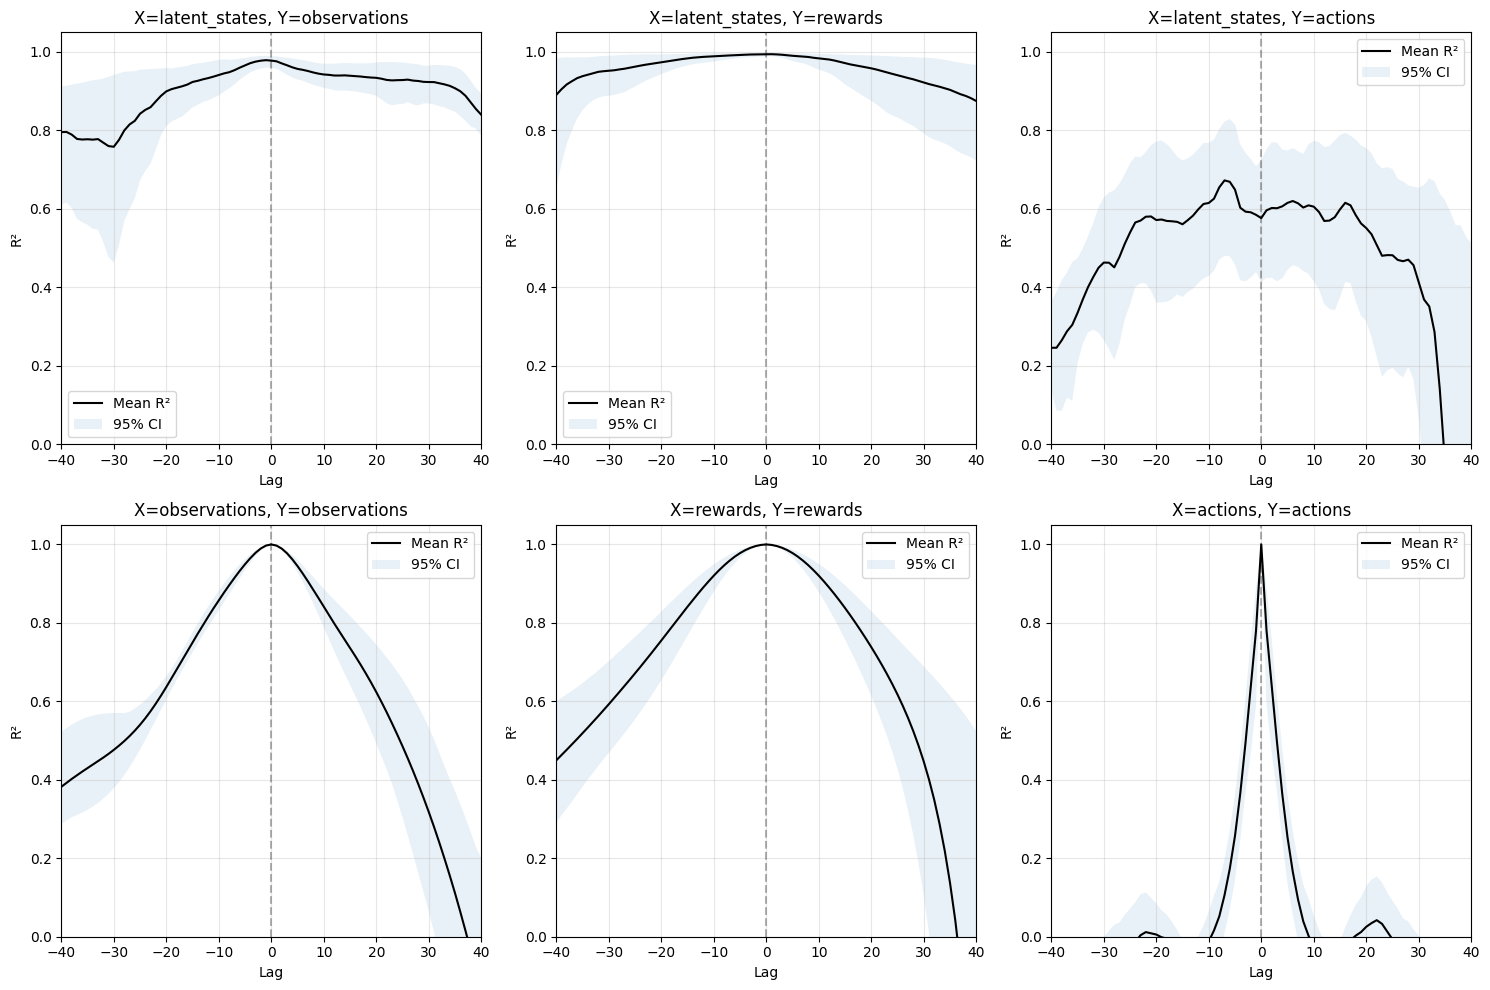

In [17]:
# Load the results from pickle file
with open('/home/hgf_hmgu/hgf_gib4562/tdmpc2/results_decoding_lasso.pkl',
          'rb') as f:
    results_decoding_lasso = pickle.load(f)

# Plot R2 means with bootstrapped confidence intervals for each combination
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (key, results) in enumerate(results_decoding_lasso.items()):
    ax = axes[idx]

    r2_mean = results['r2_mean']
    r2_ci = results['r2_ci']

    # Extract lags and R² values from the dictionary
    lags = list(r2_mean.keys())
    means = list(r2_mean.values())

    # r2_ci is a tuple of (lower_dict, upper_dict)
    ci_lower = [r2_ci[lag][0] for lag in lags]
    ci_upper = [r2_ci[lag][1] for lag in lags]

    ax.plot(lags, means, label='Mean R²', color='black')
    ax.fill_between(lags, ci_lower, ci_upper, alpha=0.1, label='95% CI')
    ax.set_xlabel('Lag')
    ax.set_ylabel('R²')
    title = key.split('-')
    ax.set_title(f'X={title[0]}, Y={title[1]}')
    ax.grid(True, alpha=0.3)
    #ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-40, 40)

plt.tight_layout()
plt.show()


## per latent LR

In [ ]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import seaborn as sns

In [ ]:
def get_model(model):
    if model == 'linear_regression':
        return LinearRegression()
    elif model == 'lasso':
        return Lasso(alpha=0.001)
    elif model == 'ridge':
        return Ridge(alpha=1.0)
    else:
        raise ValueError(f"Model {model} not supported")


def latent_semantics_leave_k_out(
    z_eps,
    y_eps,
    k_holdout=1,
    model='linear_regression',
    mode="joint",  # 'joint' or 'pairwise'
    r2_joint_mode='individual',  # 'individual' or 'global'
    max_combinations=None,
    add_bootstrap_ci=True,
    n_boot=1000,  # number of bootstrap resamples
    ci=95,  # confidence level (percent)
    random_state=0,
):
    """
    Leave-k-episodes-out CV for per-latent semantic regressions, with bootstrap CIs.

    Two modes:
        - 'joint':   y (D-dim) = W_i * z_i + b_i   (one multi-output model per latent)
        - 'pairwise': y_j = w_ij * z_i + b_ij      (one scalar model per latent–output pair)
    """
    assert mode in ("joint", "pairwise"), "mode must be 'joint' or 'pairwise'"

    n_eps = len(z_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    rng = np.random.default_rng(random_state)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        idxs = rng.choice(len(all_combos), size=max_combinations, replace=False)
        all_combos = [all_combos[i] for i in idxs]

    L = z_eps[0].shape[1]  # number of x dimensions (e.g. latent dims)
    D = y_eps[0].shape[1]  # number of y dimensions (e.g. observation dims)

    # special handling for global R² (single scalar)
    if mode == 'joint' and r2_joint_mode == 'global':
        D_out = 1
    else:
        D_out = D

    r2_by_fold = {}
    #r2_by_fold_train = {}
    fold_idx = 0

    for test_idxs in tqdm(all_combos, desc=f"Leave-{k_holdout}-out ({mode})"):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        # Concatenate training and test data
        z_train = np.concatenate([z_eps[i] for i in train_idxs], axis=0)
        y_train = np.concatenate([y_eps[i] for i in train_idxs], axis=0)
        z_test = np.concatenate([z_eps[j] for j in test_idxs], axis=0)
        y_test = np.concatenate([y_eps[j] for j in test_idxs], axis=0)

        #fold_r2_train = np.full((L, D_out), np.nan)
        fold_r2 = np.full((L, D_out), np.nan)

        if mode == "joint":
            # one multi-output regression per latent
            for i in range(L):
                xi_tr = z_train[:, i:i + 1]
                xi_te = z_test[:, i:i + 1]
                model_to_fit = get_model(model).fit(xi_tr, y_train)
                y_pred = model_to_fit.predict(xi_te)

                if r2_joint_mode == 'individual':
                    for d in range(D):
                        fold_r2[i, d] = r2_score(y_test[:, d], y_pred[:, d])
                elif r2_joint_mode == 'global':
                    fold_r2[i, 0] = r2_score(y_test,
                                             y_pred,
                                             multioutput='variance_weighted')

        elif mode == "pairwise":
            # one scalar regression per latent-output pair
            for i in range(L):
                xi_tr = z_train[:, i]
                xi_te = z_test[:, i]
                for d in range(D):
                    model_to_fit = get_model(model).fit(xi_tr.reshape(-1, 1),
                                                        y_train[:, d])
                    y_pred = model_to_fit.predict(xi_te.reshape(-1, 1))
                    fold_r2[i, d] = r2_score(y_test[:, d], y_pred)
                    # fold_r2_train[i, d] = r2_score(
                    #     y_train[:, d],
                    #     model_to_fit.predict(xi_tr.reshape(-1, 1)))
        r2_by_fold[fold_idx] = fold_r2
        #r2_by_fold_train[fold_idx] = fold_r2_train
        fold_idx += 1

    # stack folds → (n_folds, L, D_out)
    r2_stack = np.stack(list(r2_by_fold.values()), axis=0)
    r2_mean = np.nanmean(r2_stack, axis=0)
    r2_std = np.nanstd(r2_stack, axis=0, ddof=1)

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_fold': r2_by_fold,
    }

    # -----------------------------
    # Bootstrap confidence intervals
    # -----------------------------

    if add_bootstrap_ci:
        print("Computing bootstrap CIs")
        alpha_p = (100 - ci) / 2
        lower = np.full((L, D_out), np.nan)
        upper = np.full((L, D_out), np.nan)

        for i in tqdm(range(L), desc="Bootstrapping CIs"):
            for d in range(D_out):
                vals = r2_stack[:, i, d]
                vals = vals[~np.isnan(vals)]
                if len(vals) == 0:
                    continue
                boot_means = np.zeros(n_boot)
                for b in range(n_boot):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boot_means[b] = np.mean(sample)
                lower[i, d] = np.percentile(boot_means, alpha_p)
                upper[i, d] = np.percentile(boot_means, 100 - alpha_p)

        r2_ci = np.stack([lower, upper], axis=-1)  # (L, D_out, 2)
        results['r2_ci'] = r2_ci

    return results

In [ ]:
# z_eps, y_eps = list of arrays per episode

x_var = 'latent_states'
y_var = 'observations'
results = latent_semantics_leave_k_out(exp_vars[x_var],
                                       exp_vars[y_var],
                                       k_holdout=1,
                                       model='linear_regression',
                                       mode='pairwise')

Leave-1-out (pairwise):   0%|          | 0/9 [00:00<?, ?it/s]

Leave-1-out (pairwise): 100%|██████████| 9/9 [00:21<00:00,  2.39s/it]


Computing bootstrap CIs


Bootstrapping CIs: 100%|██████████| 512/512 [00:38<00:00, 13.15it/s]


In [22]:
r2_mean = results['r2_mean']
r2_std = results['r2_std']
r2_ci = results['r2_ci']
r2_by_fold = results['r2_by_fold']

In [ ]:
r2_by_fold[0]

(512, 5)

In [25]:
r2_mean.shape

(512, 5)

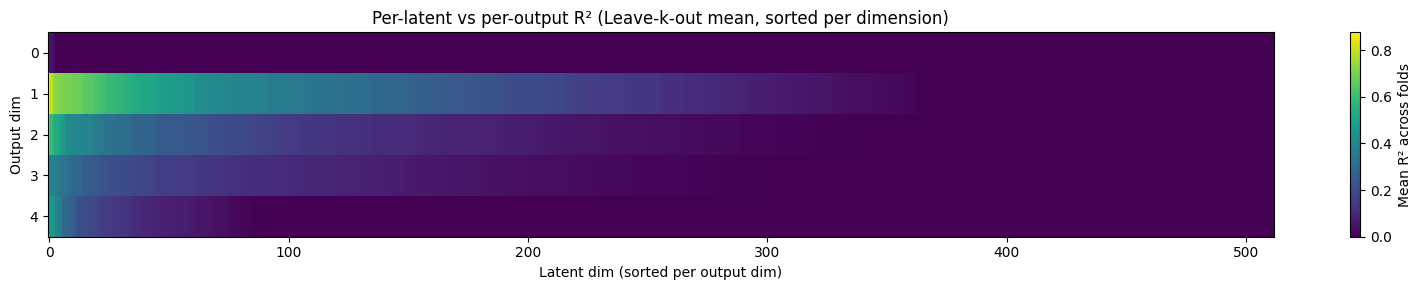

In [31]:
# Sort latent dimensions by their overall magnitude per output dimension

r2_mean = np.maximum(r2_mean, 0)

# Sort each output dimension independently by the magnitude of latent contributions
sorted_r2_mean = np.zeros_like(r2_mean)
for d in range(r2_mean.shape[1]):
    sorted_indices_d = np.argsort(r2_mean[:, d])[::-1]
    sorted_r2_mean[:, d] = r2_mean[sorted_indices_d, d]

plt.figure(figsize=(16, 3))
plt.imshow(sorted_r2_mean.T,
           cmap='viridis',
           interpolation='none',
           aspect='auto',
           vmin=0,
           vmax=r2_mean.max())

plt.colorbar(label='Mean R² across folds')
plt.xlabel('Latent dim (sorted per output dim)')
plt.ylabel('Output dim')
plt.title(
    'Per-latent vs per-output R² (Leave-k-out mean, sorted per dimension)')
plt.tight_layout()
plt.show()

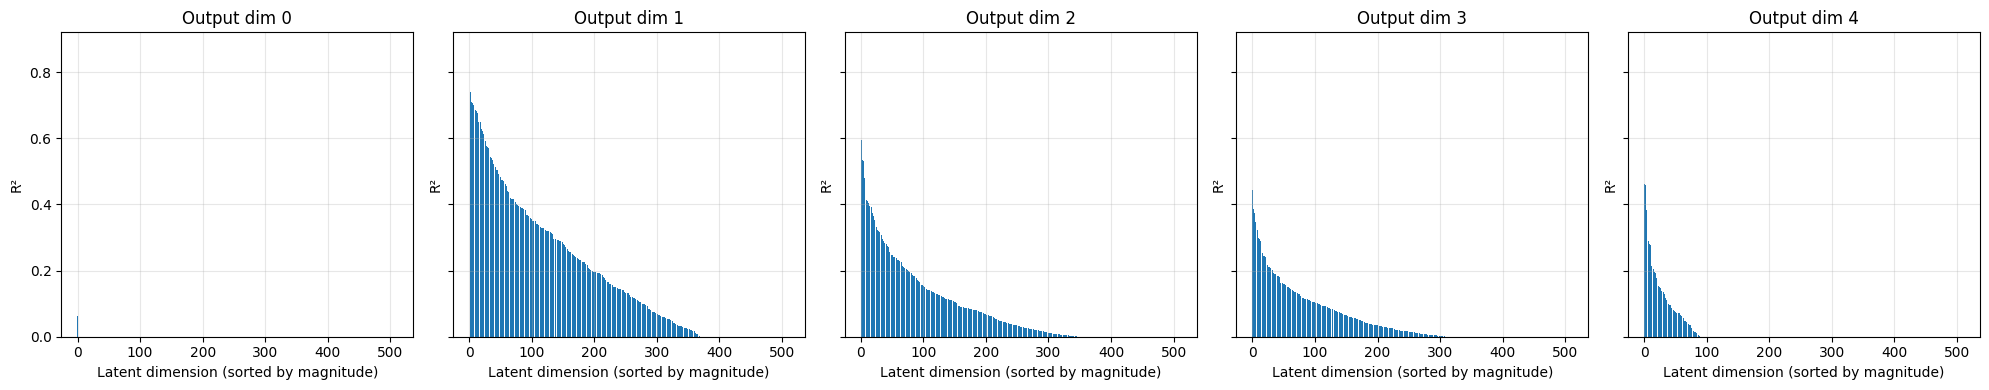

In [63]:
# Create a barplot for each output dimension showing R² vs latent dimension
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Option to sort bars by magnitude
sort_by_magnitude = True

fig, axes = plt.subplots(1,
                         n_output_dims,
                         figsize=(4 * n_output_dims, 4),
                         sharey=True)
if n_output_dims == 1:
    axes = [axes]

for d in range(n_output_dims):
    if sort_by_magnitude:
        # Sort by magnitude (descending)
        sorted_indices = np.argsort(r2_mean[:, d])[::-1]
        sorted_values = r2_mean[sorted_indices, d]
        axes[d].bar(np.arange(n_latent_dims), sorted_values)
        axes[d].set_xlabel('Latent dimension (sorted by magnitude)')
    else:
        axes[d].bar(np.arange(n_latent_dims), r2_mean[:, d])
        axes[d].set_xlabel('Latent dimension')

    axes[d].set_ylabel('R²')
    axes[d].set_title(f'Output dim {d}')
    axes[d].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Output dim 0: 0 nonzero latents
Output dim 1: 277 nonzero latents
Output dim 2: 155 nonzero latents
Output dim 3: 106 nonzero latents
Output dim 4: 39 nonzero latents

--- Pairwise Overlap Analysis ---
Dims 0 & 1: 0 shared latents (Jaccard: 0.000)
Dims 0 & 2: 0 shared latents (Jaccard: 0.000)
Dims 0 & 3: 0 shared latents (Jaccard: 0.000)
Dims 0 & 4: 0 shared latents (Jaccard: 0.000)
Dims 1 & 2: 69 shared latents (Jaccard: 0.190)
Dims 1 & 3: 59 shared latents (Jaccard: 0.182)
Dims 1 & 4: 27 shared latents (Jaccard: 0.093)
Dims 2 & 3: 42 shared latents (Jaccard: 0.192)
Dims 2 & 4: 13 shared latents (Jaccard: 0.072)
Dims 3 & 4: 21 shared latents (Jaccard: 0.169)


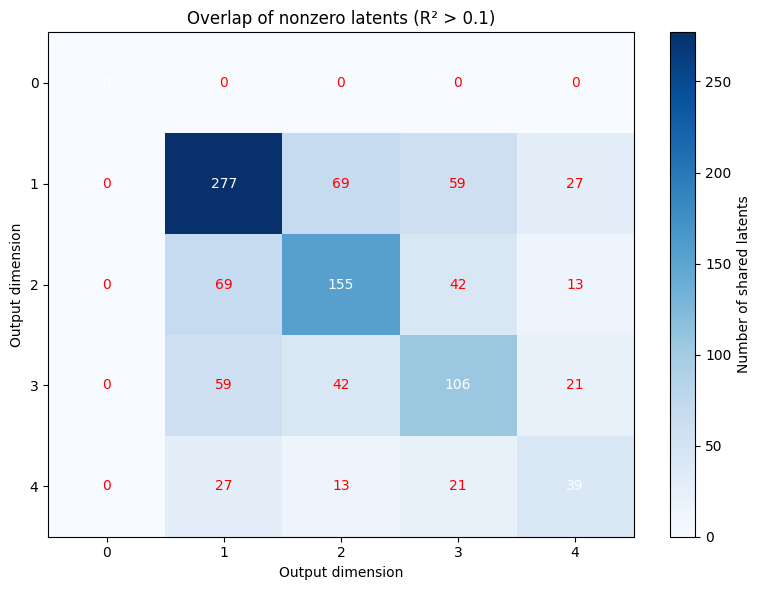

In [85]:
# Analyze overlap of nonzero latents between output dimensions
threshold = 0.1
n_output_dims = r2_mean.shape[1]
n_latent_dims = r2_mean.shape[0]

# Get nonzero latents for each output dimension
nonzero_latents = {}
for d in range(n_output_dims):
    nonzero_latents[d] = set(np.nonzero(r2_mean[:, d] > threshold)[0])
    print(f"Output dim {d}: {len(nonzero_latents[d])} nonzero latents")

print("\n--- Pairwise Overlap Analysis ---")
# Compute pairwise overlap
overlap_matrix = np.zeros((n_output_dims, n_output_dims))
for i in range(n_output_dims):
    for j in range(n_output_dims):
        overlap = len(nonzero_latents[i].intersection(nonzero_latents[j]))
        overlap_matrix[i, j] = overlap
        if i < j:
            union = len(nonzero_latents[i].union(nonzero_latents[j]))
            jaccard = overlap / union if union > 0 else 0
            print(
                f"Dims {i} & {j}: {overlap} shared latents (Jaccard: {jaccard:.3f})"
            )

# Visualize overlap matrix
plt.figure(figsize=(8, 6))
plt.imshow(overlap_matrix, cmap='Blues', aspect='auto')
plt.colorbar(label='Number of shared latents')
plt.xlabel('Output dimension')
plt.ylabel('Output dimension')
plt.title(f'Overlap of nonzero latents (R² > {threshold})')
for i in range(n_output_dims):
    for j in range(n_output_dims):
        plt.text(j,
                 i,
                 f'{int(overlap_matrix[i, j])}',
                 ha='center',
                 va='center',
                 color='red' if i != j else 'white')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import itertools
import pandas as pd


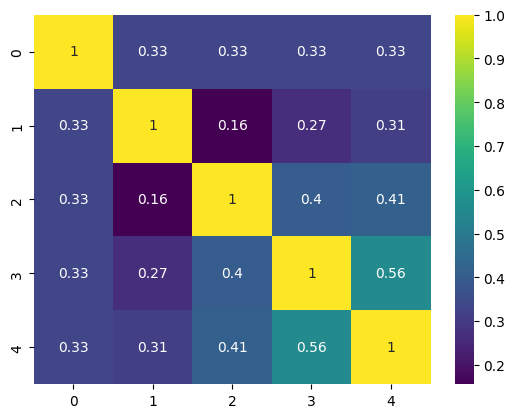

In [96]:
def compute_overlap_matrix(active_latents_dict, metric='jaccard'):
    keys = list(active_latents_dict.keys())
    n = len(keys)
    mat = np.zeros((n, n))
    for i, j in itertools.combinations(range(n), 2):
        A, B = set(active_latents_dict[keys[i]]), set(
            active_latents_dict[keys[j]])
        inter = len(A & B)
        if metric == 'jaccard':
            val = inter / len(A | B) if (A | B) else np.nan
        elif metric == 'overlap':
            val = inter / min(len(A), len(B)) if min(len(A),
                                                     len(B)) > 0 else np.nan
        else:
            raise ValueError("metric must be 'jaccard' or 'overlap'")
        mat[i, j] = mat[j, i] = val
    np.fill_diagonal(mat, 1.0)
    return pd.DataFrame(mat, index=keys, columns=keys)


def get_active_latents(r2_mean, mode='threshold', k=10, percentile=90):
    active_latents = {}
    if mode == 'threshold':
        for d in range(n_output_dims):
            active_latents[d] = np.nonzero(r2_mean[:, d] > threshold)[0]
    elif mode == 'topk':
        for d in range(n_output_dims):
            # Get indices of top k latents by R² value
            top_k_indices = np.argsort(r2_mean[:, d])[-k:]
            # Filter to only those with positive R²
            active_latents[d] = top_k_indices[r2_mean[top_k_indices, d] > 0]
    elif mode == 'percentile':
        for d in range(n_output_dims):
            # Compute percentile threshold for this dimension
            pct_threshold = np.percentile(r2_mean[:, d], percentile)
            active_latents[d] = np.nonzero(r2_mean[:, d] > pct_threshold)[0]
    else:
        raise ValueError("mode must be 'threshold', 'topk', or 'percentile'")
    return active_latents


active_latents = get_active_latents(r2_mean, mode='percentile', percentile=70)
overlap_df = compute_overlap_matrix(active_latents, metric='overlap')

sns.heatmap(overlap_df, annot=True, cmap='viridis')
plt.show()